# SEIRD ABM — Model Initialization
### Bayesian Agent-Based Model of Infectious Disease Transmission in an Urban Center

This notebook implements **Section 5 (Initialization)** of the ODD Protocol.  
It creates the spatial environment, populates it with agents, assigns all attributes  
stochastically, seeds the initial epidemic state, and produces diagnostic plots.

---
**ODD Reference:** §2 (Entities & Variables), §2.3 (Environment), §5 (Initialization)

## 0. Imports & Path Setup

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Project modules
from config.parameters import *
from agents.individual import Individual, EpiState, TransportMode, AgeGroup, ResidenceZone
from agents.health_ministry import HealthMinistry, AlertState
from environment.grid import Grid, ZoneType

# Reproducible RNG
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print("✓ Imports successful")

✓ Imports successful


---
## 1. Initialize the Spatial Environment

**ODD §2.3:** The environment is a `100 × 100` grid partitioned into:
- **Urban core** – central 40 × 40 cells (work zone for all agents)
- **Dense periphery** – 15 × 20 top-left block (poorer neighborhood)
- **Sparse periphery** – all remaining cells (lower-density residential)

In [4]:
grid = Grid(
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    max_per_cell=MAX_AGENTS_PER_CELL,
)

zone_counts = grid.zone_cell_counts()
print("Grid initialized:")
for zone, count in zone_counts.items():
    print(f"  {zone:<22}: {count:>5} cells")
print(f"  {'Total':<22}: {sum(zone_counts.values()):>5} cells")

Grid initialized:
  urban_core            :  1600 cells
  dense_periphery       :   300 cells
  sparse_periphery      :  8100 cells
  Total                 : 10000 cells


/var/folders/qz/btw5rh0d135dqkc_dh4v8z_80000gn/T/ipykernel_37769/4052039953.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set2", 3)


FileNotFoundError: [Errno 2] No such file or directory: '../data/outputs/zone_layout.png'

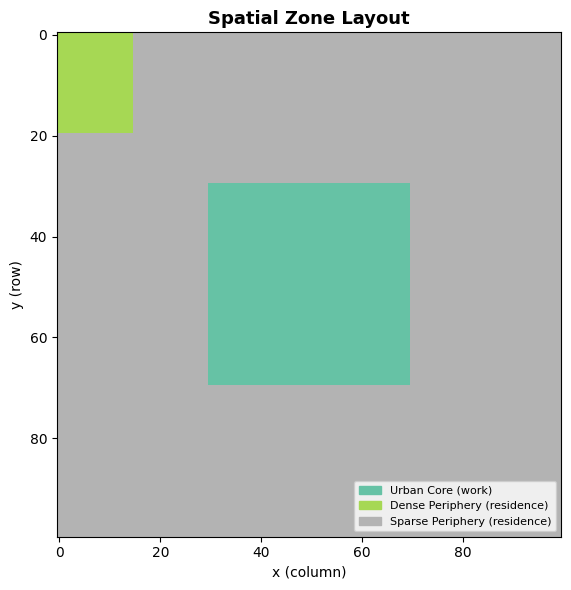

In [6]:
# ── Visualize zone layout ────────────────────────────────────────────────────
zone_color_map = {
    ZoneType.URBAN_CORE:       0,
    ZoneType.DENSE_PERIPHERY:  1,
    ZoneType.SPARSE_PERIPHERY: 2,
}
numeric_map = np.vectorize(lambda z: zone_color_map[z])(grid.zone_map)

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.get_cmap("Set2", 3)
ax.imshow(numeric_map, cmap=cmap, origin="upper", vmin=-0.5, vmax=2.5)
ax.set_title("Spatial Zone Layout", fontsize=13, fontweight="bold")
ax.set_xlabel("x (column)")
ax.set_ylabel("y (row)")
legend_patches = [
    mpatches.Patch(color=cmap(0), label="Urban Core (work)"),
    mpatches.Patch(color=cmap(1), label="Dense Periphery (residence)"),
    mpatches.Patch(color=cmap(2), label="Sparse Periphery (residence)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../data/outputs/zone_layout.png", dpi=120)
plt.show()
print("Zone layout saved.")

---
## 2. Spawn & Attribute Individual Agents

**ODD §5:** Agents are stochastically assigned:
- Residence zone (dense vs. sparse periphery)
- Age group (affects fatality rate)
- Transport preference (affects transmission multiplier)
- Sensibility to public-health plan (Beta prior, residence-dependent)
- Doctor visit probability (Bernoulli draw)

In [7]:
def assign_residence(rng: np.random.Generator) -> ResidenceZone:
    """Draw residential zone from population fractions (ODD §5)."""
    if rng.random() < RESIDENCE_FRACTION_DENSE_PERIPHERY:
        return ResidenceZone.DENSE_PERIPHERY
    return ResidenceZone.SPARSE_PERIPHERY


def assign_age_group(rng: np.random.Generator) -> AgeGroup:
    """Multinomial draw over age groups using configured fractions."""
    groups  = list(AGE_GROUPS.keys())
    probs   = [AGE_GROUPS[g]["fraction"] for g in groups]
    idx     = rng.choice(len(groups), p=probs)
    return AgeGroup[groups[idx].upper()]


def assign_transport(rng: np.random.Generator) -> TransportMode:
    """Multinomial draw over transport modes."""
    modes = list(TRANSPORT_PREFS.keys())
    probs = [TRANSPORT_PREFS[m]["fraction"] for m in modes]
    idx   = rng.choice(len(modes), p=probs)
    return TransportMode(modes[idx])


def assign_sensibility(residence: ResidenceZone, rng: np.random.Generator) -> float:
    """Beta draw; denser-periphery residents have lower mean sensibility."""
    prior = SENSIBILITY_PRIOR[residence.value]
    return float(rng.beta(prior["alpha"], prior["beta"]))


def assign_work_cell(rng: np.random.Generator) -> tuple:
    """Random cell inside the urban core."""
    x = int(rng.integers(URBAN_CORE["x_start"], URBAN_CORE["x_end"]))
    y = int(rng.integers(URBAN_CORE["y_start"], URBAN_CORE["y_end"]))
    return (x, y)


print("✓ Attribute-assignment helpers defined")

✓ Attribute-assignment helpers defined


In [8]:
# ── Create all N individual agents ──────────────────────────────────────────
individuals: list[Individual] = []

zone_to_grid_zone = {
    ResidenceZone.DENSE_PERIPHERY:  ZoneType.DENSE_PERIPHERY,
    ResidenceZone.SPARSE_PERIPHERY: ZoneType.SPARSE_PERIPHERY,
}

placement_failures = 0

for agent_id in range(POPULATION_SIZE):
    residence      = assign_residence(rng)
    age_group      = assign_age_group(rng)
    transport_pref = assign_transport(rng)
    sensibility    = assign_sensibility(residence, rng)
    doctor         = bool(rng.random() < DOCTOR_VISIT_PROB)
    work_pos       = assign_work_cell(rng)

    # Place agent in home zone
    try:
        home_pos = grid.random_cell_in_zone(zone_to_grid_zone[residence], rng)
    except RuntimeError:
        placement_failures += 1
        # Fall back to sparse periphery if dense is saturated
        home_pos = grid.random_cell_in_zone(ZoneType.SPARSE_PERIPHERY, rng)

    agent = Individual(
        agent_id       = agent_id,
        residence      = residence,
        work_place     = WORK_ZONE,
        age_group      = age_group,
        transport_pref = transport_pref,
        sensibility_plan = sensibility,
        doctor         = doctor,
        home_position  = home_pos,
        position       = home_pos,
        work_position  = work_pos,
    )

    grid.place_agent(agent_id, *home_pos)
    individuals.append(agent)

print(f"✓ {len(individuals)} agents created and placed")
if placement_failures:
    print(f"  ⚠ {placement_failures} fallback placements (dense periphery saturated)")

✓ 5000 agents created and placed
  ⚠ 241 fallback placements (dense periphery saturated)


---
## 3. Verify Attribute Distributions

In [9]:
df = pd.DataFrame([
    {
        "agent_id":        a.agent_id,
        "residence":       a.residence.value,
        "age_group":       a.age_group.value,
        "transport_pref":  a.transport_pref.value,
        "sensibility":     round(a.sensibility_plan, 4),
        "doctor":          a.doctor,
        "epi_state":       a.epi_state.name,
    }
    for a in individuals
])

print("=== Sample agents ===")
display(df.head(8))

print("\n=== Residence distribution ===")
display(df["residence"].value_counts(normalize=True).rename("fraction").to_frame())

print("\n=== Age group distribution ===")
display(df["age_group"].value_counts(normalize=True).rename("fraction").to_frame())

print("\n=== Transport preference ===")
display(df["transport_pref"].value_counts(normalize=True).rename("fraction").to_frame())

print(f"\nDoctor-visiting agents: {df['doctor'].sum()} ({df['doctor'].mean():.1%})")

=== Sample agents ===


,agent_id,residence,age_group,transport_pref,sensibility,doctor,epi_state
0,0,sparse_periphery,young,walking,0.9026,False,SUSCEPTIBLE
1,1,dense_periphery,adult,car,0.2444,True,SUSCEPTIBLE
2,2,sparse_periphery,young,public_transit,0.2874,False,SUSCEPTIBLE
3,3,sparse_periphery,child,walking,0.9615,True,SUSCEPTIBLE
4,4,sparse_periphery,young,walking,0.3122,True,SUSCEPTIBLE
5,5,sparse_periphery,young,walking,0.9175,True,SUSCEPTIBLE
6,6,sparse_periphery,adult,car,0.6333,True,SUSCEPTIBLE
7,7,dense_periphery,young,walking,0.3400,True,SUSCEPTIBLE



=== Residence distribution ===


,fraction
residence,
sparse_periphery,0.6518
dense_periphery,0.3482



=== Age group distribution ===


,fraction
age_group,
adult,0.3610
young,0.3068
senior,0.1864
child,0.1458



=== Transport preference ===


,fraction
transport_pref,
public_transit,0.4976
car,0.3072
walking,0.1952



Doctor-visiting agents: 3009 (60.2%)


FileNotFoundError: [Errno 2] No such file or directory: '../data/outputs/sensibility_distributions.png'

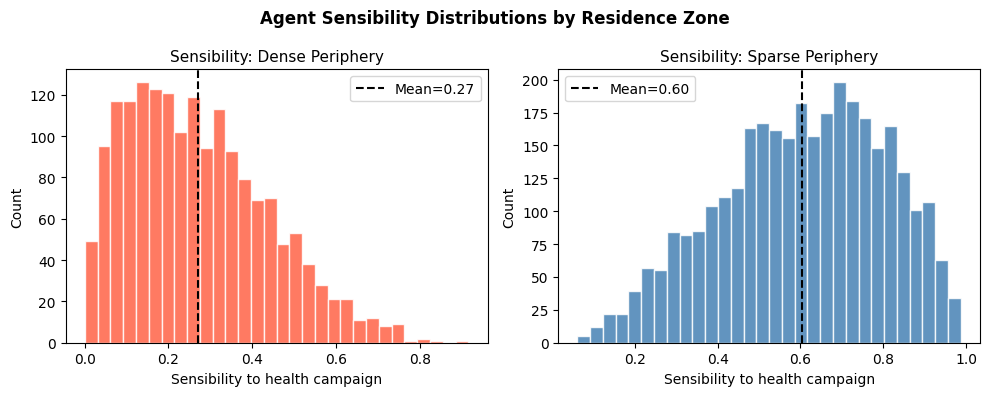

In [10]:
# ── Plot sensibility distributions by residence ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, zone in zip(axes, ["dense_periphery", "sparse_periphery"]):
    vals = df.loc[df["residence"] == zone, "sensibility"]
    ax.hist(vals, bins=30, color="steelblue" if zone == "sparse_periphery" else "tomato",
            edgecolor="white", alpha=0.85)
    ax.set_title(f"Sensibility: {zone.replace('_', ' ').title()}", fontsize=11)
    ax.set_xlabel("Sensibility to health campaign")
    ax.set_ylabel("Count")
    ax.axvline(vals.mean(), color="black", linestyle="--", label=f"Mean={vals.mean():.2f}")
    ax.legend()

plt.suptitle("Agent Sensibility Distributions by Residence Zone", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/outputs/sensibility_distributions.png", dpi=120)
plt.show()

---
## 4. Seed Initial Epidemic Conditions

**ODD §5:** A fraction of agents start `EXPOSED` or `INFECTIOUS_ASYMPTOMATIC`.  
All others start `SUSCEPTIBLE`. No agents start `RECOVERED`. No policy is active.

In [11]:
n_exposed   = int(POPULATION_SIZE * INITIAL_EXPOSED_FRACTION)   # ~25 agents
n_infected  = int(POPULATION_SIZE * INITIAL_INFECTED_FRACTION)  # ~10 agents
n_seed      = n_exposed + n_infected

# Sample unique seed agents
seed_ids = rng.choice(POPULATION_SIZE, size=n_seed, replace=False)
exposed_ids   = seed_ids[:n_exposed]
infected_ids  = seed_ids[n_exposed:]

for aid in exposed_ids:
    individuals[aid].transition_to(EpiState.EXPOSED)

for aid in infected_ids:
    # 40% asymptomatic fraction
    if rng.random() < ASYMPTOMATIC_FRACTION:
        individuals[aid].transition_to(EpiState.INFECTIOUS_ASYMPTOMATIC)
    else:
        individuals[aid].transition_to(EpiState.INFECTIOUS_SYMPTOMATIC)

# Tally initial epidemic state
state_counts = Counter(a.epi_state.name for a in individuals)
print("Initial epidemic state:")
for state, count in sorted(state_counts.items()):
    pct = count / POPULATION_SIZE * 100
    print(f"  {state:<32}: {count:>5}  ({pct:.2f}%)")

Initial epidemic state:
  EXPOSED                         :    25  (0.50%)
  INFECTIOUS_ASYMPTOMATIC         :     5  (0.10%)
  INFECTIOUS_SYMPTOMATIC          :     5  (0.10%)
  SUSCEPTIBLE                     :  4965  (99.30%)


/var/folders/qz/btw5rh0d135dqkc_dh4v8z_80000gn/T/ipykernel_37769/3553048576.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.imshow(numeric_map, cmap=plt.cm.get_cmap("Pastel2", 3), origin="upper",


FileNotFoundError: [Errno 2] No such file or directory: '../data/outputs/initial_agent_placement.png'

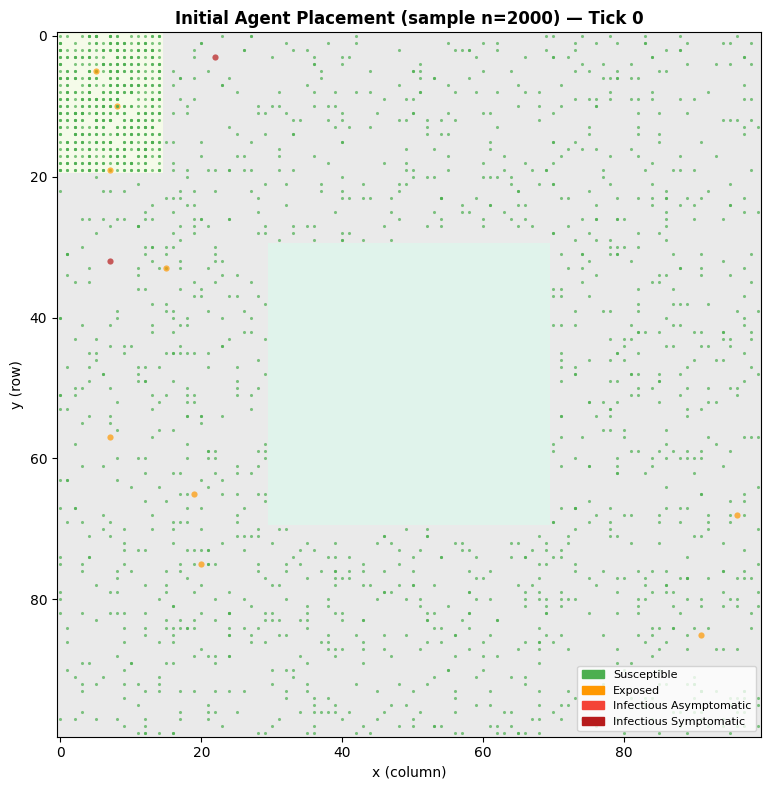

In [12]:
# ── Visualize seeded agent locations ─────────────────────────────────────────
state_colors = {
    EpiState.SUSCEPTIBLE:             "#4CAF50",
    EpiState.EXPOSED:                 "#FF9800",
    EpiState.INFECTIOUS_ASYMPTOMATIC: "#F44336",
    EpiState.INFECTIOUS_SYMPTOMATIC:  "#B71C1C",
    EpiState.RECOVERED:               "#2196F3",
    EpiState.DEAD:                    "#212121",
}

fig, ax = plt.subplots(figsize=(8, 8))

# Background zone map
ax.imshow(numeric_map, cmap=plt.cm.get_cmap("Pastel2", 3), origin="upper",
          vmin=-0.5, vmax=2.5, alpha=0.4)

# Plot agent dots (sample 2000 to keep it readable)
sample = rng.choice(len(individuals), size=min(2000, len(individuals)), replace=False)
for idx in sample:
    agent = individuals[idx]
    x, y  = agent.position
    color = state_colors[agent.epi_state]
    size  = 20 if agent.is_contagious else 5
    ax.scatter(x, y, c=color, s=size, alpha=0.7, linewidths=0)

legend_patches = [
    mpatches.Patch(color=c, label=s.replace("_", " ").title())
    for s, c in {
        "SUSCEPTIBLE": state_colors[EpiState.SUSCEPTIBLE],
        "EXPOSED": state_colors[EpiState.EXPOSED],
        "INFECTIOUS ASYMPTOMATIC": state_colors[EpiState.INFECTIOUS_ASYMPTOMATIC],
        "INFECTIOUS SYMPTOMATIC":  state_colors[EpiState.INFECTIOUS_SYMPTOMATIC],
    }.items()
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
ax.set_title("Initial Agent Placement (sample n=2000) — Tick 0",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x (column)")
ax.set_ylabel("y (row)")
plt.tight_layout()
plt.savefig("../data/outputs/initial_agent_placement.png", dpi=120)
plt.show()

---
## 5. Initialize the Health Ministry

**ODD §2.1, §3:** The ministry starts with no active alert. It will begin receiving
daily reports once the simulation loop runs. Surveillance window = 7 days.

In [13]:
health_ministry = HealthMinistry(
    alert_state               = AlertState.NO_ALERT,
    min_policy_duration_ticks = MIN_POLICY_DURATION_DAYS * TICKS_PER_DAY,
    threshold_alert_1         = POLICY_THRESHOLD_ALERT_1,
    threshold_alert_2         = POLICY_THRESHOLD_ALERT_2,
    threshold_alert_3         = POLICY_THRESHOLD_ALERT_3,
    population_size           = POPULATION_SIZE,
)

print("Health Ministry initialized:")
print(f"  Alert state         : {health_ministry.alert_state.name}")
print(f"  7-day prevalence    : {health_ministry.seven_day_prevalence:.2%}")
print(f"  Alert-1 threshold   : {POLICY_THRESHOLD_ALERT_1:.0%}")
print(f"  Alert-2 threshold   : {POLICY_THRESHOLD_ALERT_2:.0%}")
print(f"  Alert-3 threshold   : {POLICY_THRESHOLD_ALERT_3:.0%}")
print(f"  Min policy duration : {MIN_POLICY_DURATION_DAYS} days")

Health Ministry initialized:
  Alert state         : NO_ALERT
  7-day prevalence    : 0.00%
  Alert-1 threshold   : 2%
  Alert-2 threshold   : 5%
  Alert-3 threshold   : 10%
  Min policy duration : 14 days


---
## 6. Global State Summary & Sanity Checks

In [14]:
print("═" * 55)
print("  SEIRD ABM — Initialization Summary")
print("═" * 55)
print(f"  Population size         : {POPULATION_SIZE:,}")
print(f"  Grid dimensions         : {GRID_WIDTH} × {GRID_HEIGHT}")
print(f"  Simulation ticks        : {TOTAL_TICKS:,}  ({SIMULATION_DAYS} days)")
print(f"  Tick resolution         : {TICKS_PER_DAY} ticks/day (12 h each)")
print()
print("  ── Agents ──")
res_counts = Counter(a.residence.value for a in individuals)
for zone, n in res_counts.items():
    print(f"    Residence – {zone:<22}: {n:>5}  ({n/POPULATION_SIZE:.1%})")
print()
print("  ── Epidemic seed ──")
for state, count in sorted(state_counts.items()):
    print(f"    {state:<32}: {count:>5}")
print()
print("  ── Health Ministry ──")
print(f"    Initial alert state     : {health_ministry.alert_state.name}")
print("═" * 55)

═══════════════════════════════════════════════════════
  SEIRD ABM — Initialization Summary
═══════════════════════════════════════════════════════
  Population size         : 5,000
  Grid dimensions         : 100 × 100
  Simulation ticks        : 730  (365 days)
  Tick resolution         : 2 ticks/day (12 h each)

  ── Agents ──
    Residence – sparse_periphery      :  3259  (65.2%)
    Residence – dense_periphery       :  1741  (34.8%)

  ── Epidemic seed ──
    EXPOSED                         :    25
    INFECTIOUS_ASYMPTOMATIC         :     5
    INFECTIOUS_SYMPTOMATIC          :     5
    SUSCEPTIBLE                     :  4965

  ── Health Ministry ──
    Initial alert state     : NO_ALERT
═══════════════════════════════════════════════════════


In [ ]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
assert len(individuals) == POPULATION_SIZE, "Population size mismatch"
assert len(grid.agent_positions) == POPULATION_SIZE, "Not all agents placed on grid"
assert all(a.epi_state != EpiState.RECOVERED for a in individuals), \
    "No agent should start recovered"
assert health_ministry.alert_state == AlertState.NO_ALERT, \
    "Ministry should start with no active policy"
assert all(grid.occupancy[y, x] <= MAX_AGENTS_PER_CELL
           for (x, y) in grid.agent_positions.values()), \
    "Cell capacity exceeded"

print("✓ All sanity checks passed — model is ready for simulation!")

---
## 7. Export Initial State

Save the initial agent table to `data/outputs/` for reproducibility and later analysis.

In [15]:
os.makedirs("../data/outputs", exist_ok=True)

init_df = pd.DataFrame([
    {
        "agent_id":        a.agent_id,
        "residence":       a.residence.value,
        "age_group":       a.age_group.value,
        "transport_pref":  a.transport_pref.value,
        "sensibility":     round(a.sensibility_plan, 6),
        "doctor":          int(a.doctor),
        "home_x":          a.home_position[0],
        "home_y":          a.home_position[1],
        "work_x":          a.work_position[0],
        "work_y":          a.work_position[1],
        "initial_epi_state": a.epi_state.name,
    }
    for a in individuals
])

output_path = "../data/outputs/initial_agent_state.csv"
init_df.to_csv(output_path, index=False)
print(f"✓ Initial agent state saved to {output_path}")
display(init_df.describe(include="all").T[["count", "unique", "top", "mean", "std"]].dropna(how="all"))

✓ Initial agent state saved to ../data/outputs/initial_agent_state.csv


,count,unique,top,mean,std
agent_id,5000.0,NaN,NaN,2499.5,1443.520003
residence,5000,2,sparse_periphery,NaN,NaN
age_group,5000,4,adult,NaN,NaN
transport_pref,5000,3,public_transit,NaN,NaN
sensibility,5000.0,NaN,NaN,0.488113,0.246382
doctor,5000.0,NaN,NaN,0.6018,0.489576
home_x,5000.0,NaN,NaN,37.5302,32.57867
home_y,5000.0,NaN,NaN,38.854,32.069418
work_x,5000.0,NaN,NaN,49.2934,11.537415
work_y,5000.0,NaN,NaN,49.3922,11.605262


---
## 8. Next Steps

The model is fully initialized. The next notebook (`02_simulation_loop.ipynb`) will implement:

1. **Morning tick** – commute decision (mobility submodel §7.1)
2. **Contact & transmission** – SEIRD exposure events (§7.2)
3. **Disease progression** – stochastic state transitions (§7.3)
4. **Medical consultation** – doctor reporting to ministry (§7.4)
5. **Evening tick** – return commute
6. **Daily ministry update** – surveillance and policy activation (§7.5)
7. **Observation collection** – aggregate SEIRD counts every 2 ticks